In [1]:
import os
import math
import torch
from torch.nn.functional import softplus
from datetime import datetime
from tensorboardX import SummaryWriter
from nn.neural_network_dens2 import NeuralNetwork
from training.parse_command_line_arguments import parse_command_line_arguments
from training.util import generate_id, empty_error_dict, compute_error_dict
from training.density_dataset import AtomsDensityData
from training.hamiltonian_dataset import seeded_random_split
from training.exponential_moving_average import ExponentialMovingAverage
from training.lookahead import Lookahead
from training.batch_loader import BatchLoader
from nn.modules.spherical_harmonics_expansion import SphericalHarmonicsExpansion
import numpy as np
import time
from functools import partial
from training.grids import cubical_grid, cubical_sampling

%load_ext autoreload
%autoreload 2

In [2]:
#directory = '2020-08-20_LuCuJBCl'  # load directory name
#model_name = 'LuCuJBCl'
# sq model
# directory = '2020-09-23_gtvoM9WL'  # load directory name
# model_name = 'gtvoM9WL'
directory = '2020-09-28_YxazEPiG'  # load directory name
model_name = 'YxazEPiG'

#directory = '2020-04-30_To0wdEze'
checkpoint_dir = os.path.join(
    directory, 'checkpoints')  # checkpoint directory
# load latest checkpoint
checkpoint = torch.load(os.path.join(
    checkpoint_dir, 'latest_checkpoint.pth'), map_location='cpu')
latest_checkpoint = checkpoint['epoch']
ID = checkpoint['ID']  # load ID
args = checkpoint['args']  # overwrite args
args.use_gpu = False
args.load_from = os.path.join(directory, 'best_' + model_name + '.pth')

In [3]:
use_gpu = args.use_gpu and torch.cuda.is_available()

# load dataset(s)
print("loading density from" + args.dens_dataset + "...")
print("loading atoms from" + args.np_dataset + "...")

# density_file = '/home/mihail/data/water_rot/full_densities.hdf5'
# np_file = 'h2o_overlap_static.npy'

#args.num_workers = 0
#args.dens_dataset = 'datasets/h2o_dynamic_pyscf_dft_f_en.npy'

dataset = AtomsDensityData(np_path=args.np_dataset, density_path=args.dens_dataset,
                           orbitals_path=args.orbitals_file,
                           density_n_samp=args.density_subsamples,
                           required_properties=['density'],
                           center_positions=False,
                           radial_coeffs_file=args.radial_coeffs_file,
                           dtype=args.dtype)

loading density fromdatasets/h2o_dynamic_pyscf_dft.npy...
loading atoms fromdatasets/h2o_dynamic_centered.npy...
Starting atomsdata density init
Some variables
level 2
finished init


In [4]:
cube_grid_fn = partial(cubical_grid, nx=50, ny=50, nz=50,
                       extent=np.array([4.1483, 4.1483, 4.1483]),
                       origin=np.array([-2.0318, -2.0318 , -2.0318]))
cube_sampling_fn = cubical_sampling

valid_cube_dataset = AtomsDensityData(np_path=args.np_dataset, density_path=args.dens_dataset,
                                      orbitals_path=args.orbitals_file,
                                      density_n_samp=10000000000,
                                      required_properties=['density'],
                                      center_positions=False,
                                      radial_coeffs_file=args.radial_coeffs_file,
                                      dtype=args.dtype,
                                      grid_fn=cube_grid_fn,
                                      sampling_fn=cube_sampling_fn)

Starting atomsdata density init
Some variables
finished init


In [5]:
# determine weights of different quantities for scaling loss
sampler = torch.utils.data.BatchSampler(torch.utils.data.SequentialSampler(dataset),
                                              batch_size=6, drop_last=False)

data_loader = BatchLoader(dataset, batch_sampler=sampler,
                                num_workers=args.num_workers, pin_memory=use_gpu)
loss_weights = {}
loss_weights['density'] = args.density_weight
loss_weights['energy'] = args.energy_weight

valid_cube_sampler = torch.utils.data.BatchSampler(torch.utils.data.RandomSampler(valid_cube_dataset),
                                                   batch_size=args.valid_batch_size, drop_last=False)
valid_cube_loader = BatchLoader(valid_cube_dataset, batch_sampler=valid_cube_sampler,
                                num_workers=args.num_workers, pin_memory=use_gpu)


In [6]:
rad_iterator = iter(data_loader)
cube_iterator = iter(valid_cube_loader)

In [7]:
# define model
if args.load_from is None:
    equiv_model = NeuralNetwork(
        orbitals=dataset.orbitals,
        order=args.order,
        num_features=args.num_features,
        num_basis_functions=args.num_basis_functions,
        num_modules=args.num_modules,
        num_residual_pre_x=args.num_residual_pre_x,
        num_residual_post_x=args.num_residual_post_x,
        num_residual_pre_vi=args.num_residual_pre_vi,
        num_residual_pre_vj=args.num_residual_pre_vj,
        num_residual_post_v=args.num_residual_post_v,
        num_residual_output=args.num_residual_output,
        num_radial_components=args.num_radial_components,
        basis_functions=args.basis_functions,
        cutoff=args.cutoff,
        activation=args.activation)
    expansion_model = SphericalHarmonicsExpansion(dataset.orbitals,
                                                  radial_coeffs=dataset.radial_coeffs)
else:
    equiv_model = NeuralNetwork(load_from=args.load_from)
    expansion_model = SphericalHarmonicsExpansion(dataset.orbitals, radial_coeffs=dataset.radial_coeffs, expansion_constraint=args.expansion_constraint, integral_constraint=args.integral_constraint)

    

# convert the model to the correct dtype
equiv_model.to(args.dtype)
expansion_model.to(args.dtype)

# send model to GPU (if use_gpu is True)
if use_gpu:
    equiv_model.cuda()
    expansion_model.cuda()


saved state dict_keys(['state_dict', 'orbitals', 'order', 'num_features', 'num_basis_functions', 'num_radial_components', 'num_modules', 'num_residual_pre_x', 'num_residual_post_x', 'num_residual_pre_vi', 'num_residual_pre_vj', 'num_residual_post_v', 'num_residual_output', 'basis_functions', 'cutoff', 'activation', 'Zmax'])
An orbital with L=5 was found, but the neural network was initialized with L=6
The neural network SHOULD have at least twice the order of the maximum order orbital for good results!
orbital_spec [[(8, 11, 0), (8, 8, 1), (8, 6, 2), (8, 4, 3), (8, 3, 4), (8, 2, 5)], [(1, 5, 0), (1, 4, 1), (1, 4, 2), (1, 3, 3), (1, 2, 4)], [(1, 5, 0), (1, 4, 1), (1, 4, 2), (1, 3, 3), (1, 2, 4)]]
cg_matrix shape torch.Size([121, 121, 121])
L_counts [16, 12, 10, 7, 5, 2, 0, 0, 0, 0, 0, 0, 0]
L_dict {(8, 0): range(0, 11), (8, 1): range(0, 8), (8, 2): range(0, 6), (8, 3): range(0, 4), (8, 4): range(0, 3), (8, 5): range(0, 2), (1, 0): range(11, 16), (1, 1): range(8, 12), (1, 2): range(6, 10

In [8]:
equiv_module = equiv_model
expansion_module = expansion_model

# for keeping an exponential moving average of the model parameters (usually leads to better models)
if checkpoint is not None:  # no checkpoint is specified
    step = checkpoint['step']
    epoch = checkpoint['epoch']
    best_errors = checkpoint['best_errors']
    valid_errors = checkpoint['valid_errors']
    equiv_module.load_state_dict(checkpoint['model_state_dict'])
# or initialize step / epoch to 0 and errors to infinity
else:
    step = 0
    epoch = 0
    best_errors = empty_error_dict(loss_weights, fill_value=math.inf)
    valid_errors = empty_error_dict(loss_weights, fill_value=math.inf)



In [9]:
print('best errors', best_errors)
print('valid_errors', valid_errors)

best errors {'loss': 3.621094219852239e-05, 'density_mae': 6.603490476209117e-06, 'density_rmse': 2.9607451665469856e-05}
valid_errors {'loss': 3.858002810375183e-05, 'density_mae': 6.617926231911043e-06, 'density_rmse': 3.196210127498489e-05}


<IPython.core.display.Javascript object>


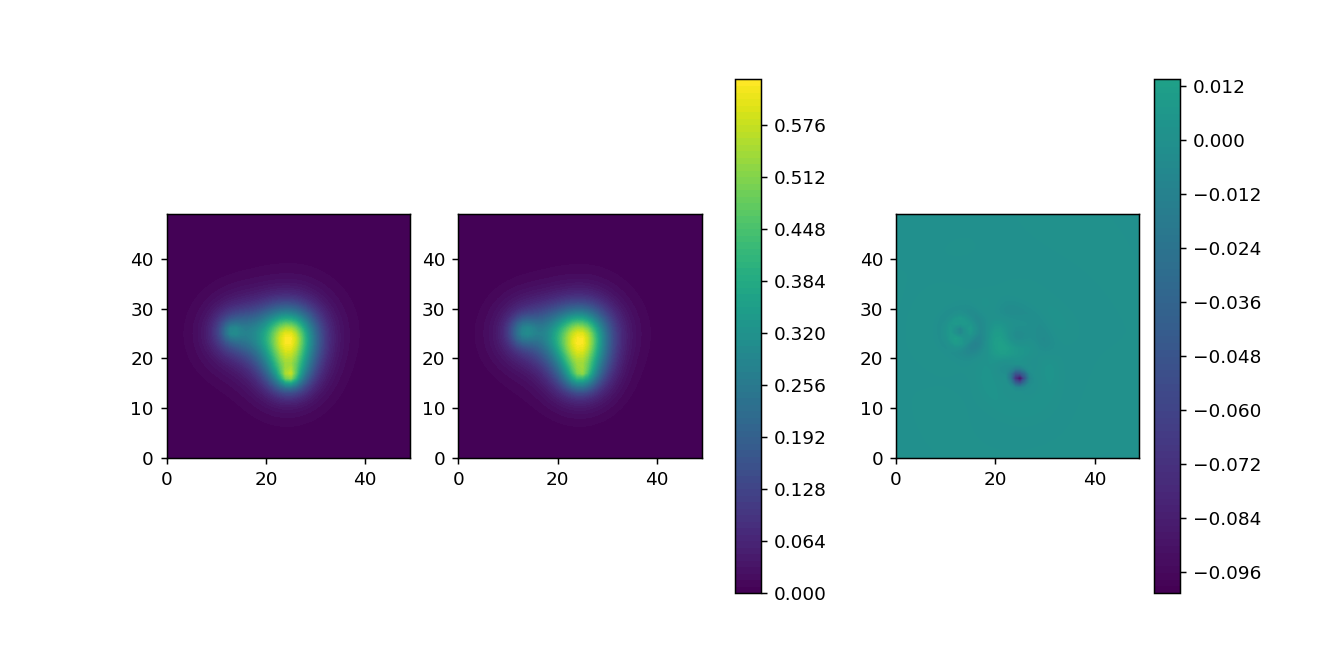

dens shape (125000,)
idx [    19   2519   5019 ... 119969 122469 124969]
coords space shape torch.Size([1, 125000, 3])
pos shape torch.Size([1, 3, 3])
positions type torch.FloatTensor
xs1 H1 tensor([[[ 0.0905,  1.0678,  1.4146,  1.0093, -0.7183,  0.2311, -0.7731,
          -0.8233, -0.4451, -0.8342,  0.2947,  0.2370,  0.9836, -0.7008,
           1.4557, -1.2597, -1.0662, -0.5876,  1.3699, -1.3190, -0.6477,
          -0.1288,  1.2125, -1.0406,  0.9424, -0.8278,  1.5002, -0.7683,
           1.4714,  1.1403,  1.5173, -1.4393, -0.1832,  1.2567,  0.3760,
          -1.2024,  1.4884, -0.6452, -0.2096, -1.2670, -0.7104,  1.5625,
           0.6749, -1.6679,  0.9911,  0.4719,  0.7261, -0.8807, -0.5467,
           1.2741, -1.2631, -0.1990, -1.3458, -1.1326, -0.9749,  1.1421,
          -1.2865,  0.1391,  0.3485, -0.8599, -0.3202, -1.5788,  0.3797,
          -0.8532, -0.3488,  0.0068,  1.5073, -0.9752, -1.0845,  1.1065,
          -0.7702, -1.5170,  0.1789, -1.0632,  0.1475, -1.5405, -0.9279,
      

/home/mihail/anaconda3/envs/equiv_dens/lib/python3.7/site-packages/torch/nn/functional.py:1614: UserWarning: nn.functional.tanh is deprecated. Use torch.tanh instead.
  warnings.warn("nn.functional.tanh is deprecated. Use torch.tanh instead.")


torch.Size([1, 125000])


In [10]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib notebook
sample = 5
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(131)
dens = np.array(valid_cube_dataset[sample]['density'].squeeze())
print('dens shape', dens.shape)
x, y  = np.meshgrid(np.arange(50), np.arange(50))
x_f = x.flatten()
y_f = y.flatten()
z_f = np.zeros_like(y_f) + 19
idx = np.ravel_multi_index((x_f, y_f, z_f), (50, 50, 50))
                
#X, Y, Z = np.meshgrid(np.arange(50) + 38, np.arange(50) + 38, np.arange(50) + 38)
#X = X.flatten()
#Y = Y.flatten()
#Z = Z.flatten()
#ndices = np.ravel_multi_index((X, Y, Z), (125, 125, 125))

print('idx', idx)
dens2d = dens[idx]
dens2d = dens2d.reshape(50, 50)

indices = np.stack((x_f, y_f, z_f), axis=1)
coords_space = valid_cube_dataset[sample]['coords']
print('coords space shape', coords_space.shape)
vmin = np.min(dens2d)
vmax = np.max(dens2d)
c1 = ax1.contourf(x, y, dens2d, vmin=vmin, vmax=vmax, levels=100)
ax1.set_aspect('equal')

positions = valid_cube_dataset[sample]['positions']
if args.use_gpu:
    positions = positions.cuda()
    coords_space = coords_space.cuda()

print('pos shape', dataset[[sample]]['positions'].shape)
print('positions type', positions.type())
coeffs = equiv_model(R=positions)
pred_dens = expansion_model(coords_space, positions,
                            coeffs['spherical_coeffs'],
                            coeffs['radial_width'],
                            coeffs['radial_scale'])



print(pred_dens['density'].shape)

p_dens = pred_dens['density'].cpu().data.squeeze().numpy()
p_dens = p_dens[idx].reshape(50, 50)

ax2 = fig.add_subplot(132)
c2 = ax2.contourf(x, y, p_dens, vmin=vmin, vmax=vmax, levels=100)
ax2.set_aspect('equal')

ax3 = fig.add_subplot(133)
c3 = ax3.contourf(x, y, p_dens-dens2d, vmin=-0.1, vmax=0.1, levels=100)
ax3.set_aspect('equal')

fig.colorbar(c2, ax=[ax1, ax2])
fig.colorbar(c3, ax=[ax3])
plt.show()

In [23]:
sample = 8
ds_sample = dataset[sample]
pos = ds_sample['positions']
coeffs = equiv_model(R=pos)
print(coeffs['spherical_coeffs'][0][(8, 0)])
print(coeffs['radial_scale'][0][(8, 0)])

print(coeffs['spherical_coeffs'][1][(1, 0)])
print(coeffs['radial_scale'][1][(1, 0)])

print(coeffs['spherical_coeffs'][2][(1, 0)])
print(coeffs['radial_scale'][2][(1, 0)])

tensor([[[[-7.2432e+00,  6.8554e+00,  7.1605e+00, -5.2441e+00,  1.6882e+00,
           -1.7502e+00,  1.0857e+00,  7.5818e-01, -3.0912e-01, -4.4330e-02,
            6.8992e-03]]]], grad_fn=<IndexBackward>)
tensor([[[[-1.0003e+01,  8.5234e+00,  9.5162e+00, -8.4458e+00,  1.1594e+00,
           -5.9726e-01,  2.9683e-03, -1.7843e-01, -1.2962e+00, -1.0494e+00,
           -9.8857e-01]]]], grad_fn=<IndexBackward>)
tensor([[[[-0.2308,  0.2375, -0.1332,  0.0030,  0.0038]]]],
       grad_fn=<IndexBackward>)
tensor([[[[-1.6629, -0.7256, -1.1185, -0.9993, -1.0045]]]],
       grad_fn=<IndexBackward>)
tensor([[[[-0.2298,  0.2374, -0.1331,  0.0032,  0.0036]]]],
       grad_fn=<IndexBackward>)
tensor([[[[-1.6630, -0.7256, -1.1183, -0.9991, -1.0045]]]],
       grad_fn=<IndexBackward>)


In [17]:
sample=5

pos = valid_cube_dataset[sample]['positions']
print('positions', pos)
coords = valid_cube_dataset[sample]['coords']
weights = valid_cube_dataset[sample]['coord_weights']
print('weights', weights)
print('coords shape', coords.shape)
dens_true = valid_cube_dataset[sample]['density']
print('density.shape', dens_true.shape)
print('density_integral', torch.sum(dens_true * weights))
dens_true_integral = torch.sum(dens_true * weights)
coeffs = equiv_model(R=pos)
dens_pred = expansion_model(coords, pos,
                            coeffs['spherical_coeffs'],
                            coeffs['radial_width'],
                            coeffs['radial_scale'])
dens_pred = dens_pred['density']
dens_pred_integral = torch.sum(dens_pred * weights)
dens_diff_integral = torch.sum(torch.abs(dens_pred - dens_true) * weights)
print('density pred integral', dens_pred_integral)
print('density_difference integral', dens_diff_integral)
print('density integral ratio', dens_diff_integral/dens_true_integral)

positions tensor([[[ 0.0000,  0.0000,  0.0000],
         [-0.9271,  0.1267, -0.5001],
         [ 0.0622, -0.6538, -0.4586]]])
weights tensor([0.0039, 0.0039, 0.0039,  ..., 0.0039, 0.0039, 0.0039])
coords shape torch.Size([1, 125000, 3])
density.shape torch.Size([1, 125000])
density_integral tensor(10.0396)
density pred integral tensor(9.8524, grad_fn=<SumBackward0>)
density_difference integral tensor(0.3198, grad_fn=<SumBackward0>)
density integral ratio tensor(0.0319, grad_fn=<DivBackward0>)


In [18]:
ds_sample = dataset[sample]
pos = ds_sample['positions']
print('positions', pos)
coords = ds_sample['coords']
weights = ds_sample['coord_weights']
print('coords shape', coords.shape)
print('weights shape', weights.shape)
dens_true = ds_sample['density']
print('density.shape', dens_true.shape)
print('density_integral', torch.sum(dens_true * weights))
print('dens_weights shape', (dens_true * weights).shape)
dens_true_integral = torch.sum(dens_true*weights)
coeffs = equiv_model(R=pos)
dens_pred = expansion_model(coords, pos,
                            coeffs['spherical_coeffs'],
                            coeffs['radial_width'],
                            coeffs['radial_scale'])
dens_pred = dens_pred['density']
dens_pred_integral = torch.sum(dens_pred * weights)
dens_diff_integral = torch.sum(torch.abs(dens_pred - dens_true) * weights)
print('density pred integral', dens_pred_integral)
print('density_difference integral', dens_diff_integral)
print('density integral ratio', dens_diff_integral/dens_true_integral)

positions tensor([[[ 0.0000,  0.0000,  0.0000],
         [-0.9271,  0.1267, -0.5001],
         [ 0.0622, -0.6538, -0.4586]]])
coords shape torch.Size([1, 22324, 3])
weights shape torch.Size([22324])
density.shape torch.Size([1, 22324])
density_integral tensor(10.2718)
dens_weights shape torch.Size([1, 22324])
density pred integral tensor(10.2741, grad_fn=<SumBackward0>)
density_difference integral tensor(0.1491, grad_fn=<SumBackward0>)
density integral ratio tensor(0.0145, grad_fn=<DivBackward0>)


In [19]:
ds_sample = dataset[sample]
pos = ds_sample['positions']
print('positions', pos)
coords = ds_sample['coords']
print('coords shape', coords.shape)
dens_true = ds_sample['density']
print('density.shape', dens_true.shape)
print('density_integral', torch.sum(dens_true))
print('dens_weights shape', (dens_true).shape)
dens_true_integral = torch.sum(dens_true)
coeffs = equiv_model(R=pos)
dens_pred = expansion_model(coords, pos,
                            coeffs['spherical_coeffs'],
                            coeffs['radial_width'],
                            coeffs['radial_scale'])
dens_pred = dens_pred['density']
dens_pred_integral = torch.sum(dens_pred)
dens_diff_integral = torch.sum(torch.abs(dens_pred - dens_true))
print('density pred integral', dens_pred_integral)
print('density_difference integral', dens_diff_integral)
print('density integral ratio', dens_diff_integral/dens_true_integral)

positions tensor([[[ 0.0000,  0.0000,  0.0000],
         [-0.9271,  0.1267, -0.5001],
         [ 0.0622, -0.6538, -0.4586]]])
coords shape torch.Size([1, 22324, 3])
density.shape torch.Size([1, 22324])
density_integral tensor(172393.0781)
dens_weights shape torch.Size([1, 22324])
density pred integral tensor(156618.1562, grad_fn=<SumBackward0>)
density_difference integral tensor(15925.1719, grad_fn=<SumBackward0>)
density integral ratio tensor(0.0924, grad_fn=<DivBackward0>)


In [20]:
ds_sample = dataset[sample]
pos = ds_sample['positions']
print('positions', pos)
coords = ds_sample['coords']
weights = ds_sample['coord_weights']

coeffs = equiv_model(R=pos)
dens_pred = expansion_model(coords, pos,
                            coeffs['spherical_coeffs'],
                            coeffs['radial_width'],
                            coeffs['radial_scale'], eval_L=[0])
dens_pred = dens_pred['density']
dens_pred_integral = torch.sum(dens_pred * weights)
print('density pred integral', dens_pred_integral)
dens_pred = expansion_model(coords, pos,
                            coeffs['spherical_coeffs'],
                            coeffs['radial_width'],
                            coeffs['radial_scale'], eval_atoms=[0], eval_L=[0])
dens_pred = dens_pred['density']
dens_pred_integral = torch.sum(dens_pred * weights)
print('density pred integral', dens_pred_integral)
dens_pred = expansion_model(coords, pos,
                            coeffs['spherical_coeffs'],
                            coeffs['radial_width'],
                            coeffs['radial_scale'], eval_atoms=[1], eval_L=[0])
dens_pred = dens_pred['density']
dens_pred_integral = torch.sum(dens_pred * weights)
print('density pred integral', dens_pred_integral)
dens_pred = expansion_model(coords, pos,
                            coeffs['spherical_coeffs'],
                            coeffs['radial_width'],
                            coeffs['radial_scale'], eval_atoms=[2], eval_L=[0])
dens_pred = dens_pred['density']
dens_pred_integral = torch.sum(dens_pred * weights)
print('density pred integral', dens_pred_integral)

positions tensor([[[ 0.0000,  0.0000,  0.0000],
         [-0.9271,  0.1267, -0.5001],
         [ 0.0622, -0.6538, -0.4586]]])
density pred integral tensor(9.5107, grad_fn=<SumBackward0>)
density pred integral tensor(7.9598, grad_fn=<SumBackward0>)
density pred integral tensor(0.7725, grad_fn=<SumBackward0>)
density pred integral tensor(0.7783, grad_fn=<SumBackward0>)
